# Assignment 7.10 Database Monitoring

I am using Postgres (allowed as per Professor Gridiron) and I installed `pg-view` and `pg-activity` on Ubuntu (ugali is my computer name):
```
pip3 install pg_view pg_activity
```

I then ran `pg_activity` which brings up some basic stats on your database like the uptime, size, number of sessions/processes and some other basic info.<p>
I noticed that the size does not seem to be accurate; I will investigate to find out why.
```bash
pg_activity -h ugali -U postgres -d postgres
```
As I ran this query below, I took a screenshot while it shows the active query; you can see I ran the query from DBeaver, an open source Query tool that can be used with Postgres, SQL Server and possibly a hundred additional databases.

```SQL
SELECT * FROM put_quote ORDER BY day_seq,etl_time_pac desc;
```
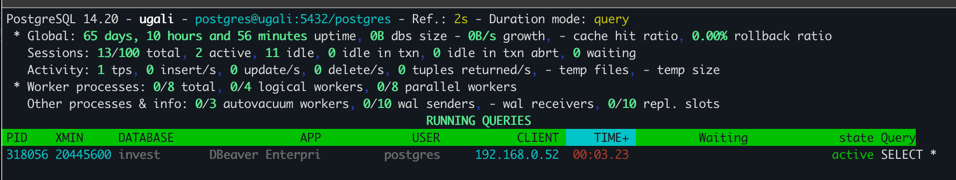

It turns out that pg_view is an older, less maintained version and it did not work with my version of Postgres. But it looks like pg_activity has all the same major features.

I restarted `pg_activity` with the switch `--db-size` and now it shows the database size:<p>
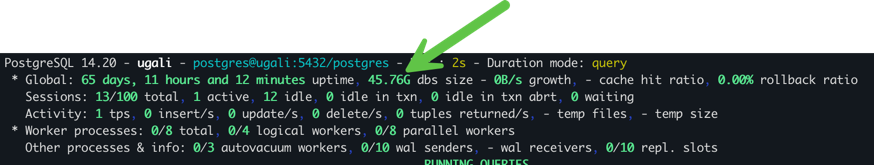<p>
Size is not calculated by default because it likely has a CPU or disk overhead; so the user needs to affirmatively pass that argument.


One big potential issue with Databases is when multiple users try to write and read the same data at the same time. I am going to simulate a "dead lock" where one user is trying to write data and another user tries to read that date before it is written to see if we can learn anything from `pg_activity`.

```sql
-- Example 1: Row-level lock using FOR UPDATE
-- Setup (run once)
DROP TABLE IF EXISTS inventory;
CREATE TABLE inventory (id serial PRIMARY KEY, qty int);
INSERT INTO inventory (qty) VALUES (10);

-- Session A:
BEGIN;
-- acquires a row lock on id=1 and holds it until COMMIT/ROLLBACK
SELECT * FROM inventory WHERE id = 1 FOR UPDATE;

-- (keep this transaction open)

-- Session B (will block until Session A commits/rolls back):
BEGIN;
-- this UPDATE needs the same row lock and will wait
UPDATE inventory SET qty = qty - 1 WHERE id = 1;
-- once Session A COMMITs, this UPDATE will complete
```
Now this is what `pg_activity` looks like:<p>
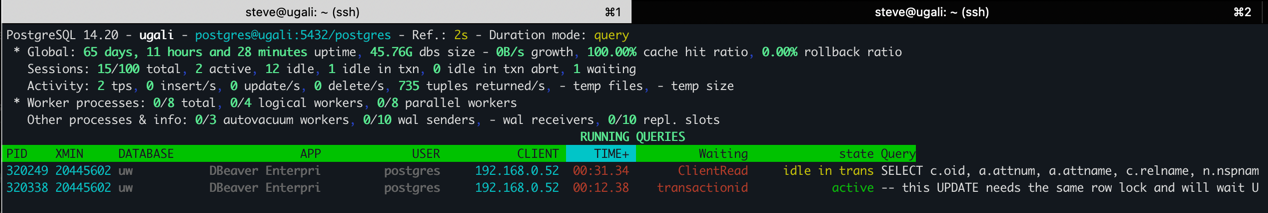

Normally, there are no queries listed here unless it is a long running query; the ones above are very small, but there is a dead lock situation where this will never complete if I don't end one of the sessions.

```sql
-- To release the lock in Session A:
COMMIT;  -- then Session B's UPDATE proceeds
```
I just committed the above transaction.<p>
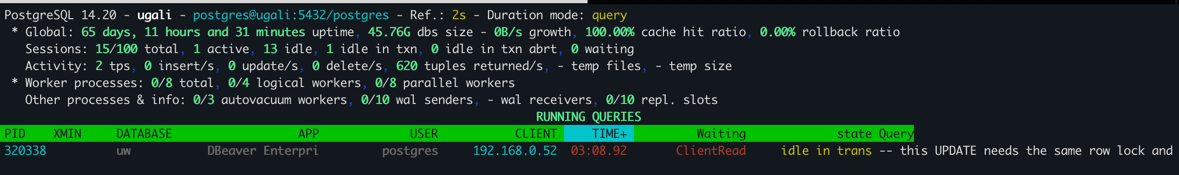

Finally, I commit Session B and all the queries dissapper:<p>
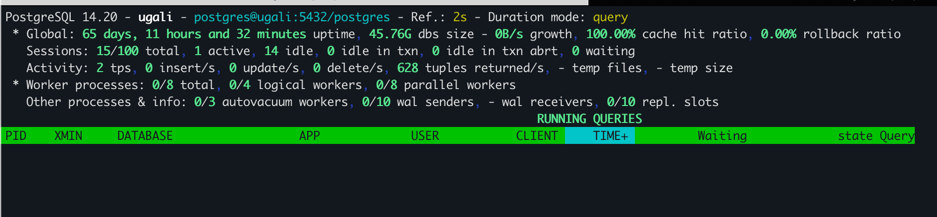

## Conclusion
pg_activity is a lightweight, practical tool for interactive monitoring:
 - it quickly reveals active queries, blocking relationships, and (with --db-size) database size.
 - pg_view should be avoided on newer Postgres versions; prefer pg_activity.
 - the locking examples validated that long-lived transactions produce visible blocking in pg_activity, making it useful for diagnosing concurrency issues.